# Phase 3b — ETH out-of-asset 검증: Donchian (ETH/USDT 4h)

## 목적

BTC Phase 3에서 생존한 **Donchian(entry_n=20, exit_n=10)**의 "낙폭 방어" 엣지가  
**ETH/USDT 4h** 라는 전혀 다른 자산에서도 재현되는지 확인한다.

| 항목 | 내용 |
|---|---|
| 검증 대상 | DonchianBreakout(entry_n=20, exit_n=10) — BTC 생존자만 |
| 자산/시간단위 | **ETH/USDT, 4h** (BTC와 다른 자산) |
| 데이터 | 2021-06-29 ~ 2026-06-28 (10,949봉, 5년) |
| 수수료 | 0.1% per side (하네스 고정) |
| 방법 | BTC Phase 3와 동일한 3축(OOS 70/30, 파라미터 민감도, 워크포워드 5구간) |

### 탈락 기준 (사전 확정 — Codex 자문 반영)
1. **OOS 생존**: OOS 구간 MDD가 같은 구간 B&H보다 의미있게 작아야 함 (낙폭 방어 재현)
2. **파라미터 견고성**: 이웃 조합 ≥60%가 B&H보다 MDD 얕음 (ETH 약세장이라 수익>0 기준 완화)
3. **구간 일관성**: 5구간 중 ≥3구간에서 B&H보다 MDD 방어

> 깔때기 철학: 탈락이 정상. BTC 생존자여도 ETH에서 실패하면 "BTC 전용 우연" 경고 → Phase 4 페이퍼 보류.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Some trades remain open at the end of backtest")
warnings.filterwarnings("ignore", message="Jupyter Notebook detected")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

import os, sys
if os.path.basename(os.getcwd()) == "research":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from backtest import load_data
from robustness import (train_test_split, time_segments, evaluate,
                        param_sweep, walk_forward, buy_hold)
from strategies.sma_cross import SmaCross
from strategies.rsi_reversion import RsiReversion
from strategies.bollinger_reversion import BollingerReversion
from strategies.donchian_breakout import DonchianBreakout
from strategies.ts_momentum import TimeSeriesMomentum
from strategies.macd_cross import MacdCross

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.1f}".format)

df = load_data("ETH/USDT", "4h")
print(f"DATA: {len(df)} bars  {df.index[0].date()} ~ {df.index[-1].date()}")

bh_full = buy_hold(df)
print(f"\nETH B&H (full): 수익 {bh_full['Return [%]']:+.1f}%  MDD {bh_full['Max. Drawdown [%]']:+.1f}%")

Loading BokehJS ...

DATA: 10949 bars  2021-06-29 ~ 2026-06-28

ETH B&H (full): 수익 -27.6%  MDD -81.1%


---
## A. 탐색 (판정 아님) — 6전략 ETH 4h 비교

BTC Phase 2d에서 했던 6전략 비교의 **ETH판**. "ETH라는 자산이 어떻게 생겼는지" 배우는 용도.

> ⚠️ **데이터스누핑 경계**: 여기서 새로 좋아 보이는 전략은 **"탐색"일 뿐 — 검증 아님**.  
> ETH 단일 관측에서 발견된 후보일 뿐이며, **별도 사전 가설 + 별도 OOS 사이클 없이는 채택하지 않는다.**  
> 이 섹션의 목적은 Donchian이 다른 전략 대비 어디에 위치하는지 맥락 파악이다.

In [2]:
STRATS = [
    ("SMA",       SmaCross),
    ("RSI",       RsiReversion),
    ("Bollinger", BollingerReversion),
    ("Donchian",  DonchianBreakout),
    ("TSMom",     TimeSeriesMomentum),
    ("MACD",      MacdCross),
]

rows = []
for name, strat in STRATS:
    m = evaluate(df, strat)
    bh = bh_full
    rows.append({
        "전략":       name,
        "Return%":   round(m["Return [%]"], 1),
        "MDD%":      round(m["Max. Drawdown [%]"], 1),
        "Sharpe":    round(m["Sharpe Ratio"], 2),
        "Trades":    int(m["# Trades"]),
        "Win%":      round(m["Win Rate [%]"], 1),
        "방어(vs B&H)": "O" if m["Max. Drawdown [%]"] > bh["Max. Drawdown [%]"] else "X",
    })

comp = pd.DataFrame(rows).set_index("전략")
display(comp)

print(f"\nETH B&H: 수익 {bh_full['Return [%]']:+.1f}%  MDD {bh_full['Max. Drawdown [%]']:+.1f}%")
print()
print("주의: 여기서 새로 좋아 보이는 전략은 '탐색'일 뿐 — 검증 아님. 데이터스누핑 경계.")
print("(ETH가 약세장이라 전 전략 음수가 정상. 탐색 목적은 Donchian 위치 파악뿐.)")

,Return%,MDD%,Sharpe,Trades,Win%,방어(vs B&H)
전략,,,,,,
SMA,-41.3,-71.4,-0.2,127,34.6,O
RSI,-69.7,-77.2,-0.7,182,42.9,O
Bollinger,-84.5,-89.2,-1.2,293,52.2,X
Donchian,-36.0,-61.6,-0.2,166,26.5,O
TSMom,-23.3,-68.0,-0.1,459,27.5,O
MACD,-31.0,-66.3,-0.2,412,33.3,O



ETH B&H: 수익 -27.6%  MDD -81.1%

주의: 여기서 새로 좋아 보이는 전략은 '탐색'일 뿐 — 검증 아님. 데이터스누핑 경계.
(ETH가 약세장이라 전 전략 음수가 정상. 탐색 목적은 Donchian 위치 파악뿐.)


---
## B. 검증 — Donchian(4h) 견고성 3축

**BTC 생존자만 대상.** Phase 3과 동일한 3축을 ETH 4h에 그대로 적용한다.  
파라미터 재조정 없음 — BTC에서 쓴 `entry_n=20, exit_n=10` 그대로.

In [3]:
# 축1 OOS (70/30)
train, test = train_test_split(df, 0.7)

rows = []
for label, d in [
    ("FULL", df),
    ("IS 앞70%", train),
    ("OOS 뒤30%", test),
]:
    m = evaluate(d, DonchianBreakout, entry_n=20, exit_n=10)
    bh = buy_hold(d)
    rows.append({
        "구간":        label,
        "기간":        f"{d.index[0].date()}~{d.index[-1].date()}",
        "봉수":        len(d),
        "전략 수익%":  round(m["Return [%]"], 1),
        "전략 MDD%":   round(m["Max. Drawdown [%]"], 1),
        "Sharpe":     round(m["Sharpe Ratio"], 2),
        "거래수":      int(m["# Trades"]),
        "B&H 수익%":  round(bh["Return [%]"], 1),
        "B&H MDD%":   round(bh["Max. Drawdown [%]"], 1),
        "낙폭방어%p":  round(bh["Max. Drawdown [%]"] - m["Max. Drawdown [%]"], 1),
    })

oos_tbl = pd.DataFrame(rows).set_index("구간")
print("=== 축1 OOS (70/30): Donchian (entry_n=20, exit_n=10) on ETH/USDT 4h ===")
display(oos_tbl)

bh_oos = buy_hold(test)
don_oos_m = evaluate(test, DonchianBreakout, entry_n=20, exit_n=10)
print(f"\nIS  기간: {train.index[0].date()} ~ {train.index[-1].date()} ({len(train)}봉)")
print(f"OOS 기간: {test.index[0].date()} ~ {test.index[-1].date()} ({len(test)}봉)")
print()
print(f"OOS B&H: 수익 {bh_oos['Return [%]']:+.1f}%  MDD {bh_oos['Max. Drawdown [%]']:+.1f}%  → 약세장")
print(f"OOS Donchian: MDD {don_oos_m['Max. Drawdown [%]']:+.1f}%  낙폭방어 {bh_oos['Max. Drawdown [%]']-don_oos_m['Max. Drawdown [%]']:+.1f}%p")
oos_defend = don_oos_m["Max. Drawdown [%]"] > bh_oos["Max. Drawdown [%]"]
print(f"→ 축1 기준 통과: {'✅ 방어 재현' if oos_defend else '❌ 방어 실패'}")

=== 축1 OOS (70/30): Donchian (entry_n=20, exit_n=10) on ETH/USDT 4h ===


,기간,봉수,전략 수익%,전략 MDD%,Sharpe,거래수,B&H 수익%,B&H MDD%,낙폭방어%p
구간,,,,,,,,,
FULL,2021-06-29~2026-06-28,10949,-36.0,-61.6,-0.2,166,-27.6,-81.1,-19.5
IS 앞70%,2021-06-29~2024-12-27,7664,-12.4,-58.4,-0.1,116,52.8,-81.1,-22.7
OOS 뒤30%,2024-12-27~2026-06-28,3285,-26.9,-43.7,-0.6,50,-53.1,-68.0,-24.3



IS  기간: 2021-06-29 ~ 2024-12-27 (7664봉)
OOS 기간: 2024-12-27 ~ 2026-06-28 (3285봉)

OOS B&H: 수익 -53.1%  MDD -68.0%  → 약세장
OOS Donchian: MDD -43.7%  낙폭방어 -24.3%p
→ 축1 기준 통과: ✅ 방어 재현


In [4]:
# 축2 파라미터 민감도 — 전체 20조합 (필터 없이)
don_grid = {"entry_n": [10, 15, 20, 25, 30], "exit_n": [5, 10, 15, 20]}
don_sweep = param_sweep(df, DonchianBreakout, don_grid)

don_sweep["beats_bh_mdd"] = don_sweep["Max. Drawdown [%]"] > bh_full["Max. Drawdown [%]"]
pos_rate = (don_sweep["Return [%]"] > 0).mean() * 100
def_rate  = don_sweep["beats_bh_mdd"].mean() * 100

print(f"=== 축2 파라미터 민감도 (ETH full, 20조합) ===")
print(f"B&H 전체 MDD: {bh_full['Max. Drawdown [%]']:+.1f}%")
print()
display(don_sweep[["entry_n","exit_n","Return [%]","Max. Drawdown [%]","Sharpe Ratio","# Trades"]].round(1))

d_base = don_sweep[(don_sweep.entry_n==20) & (don_sweep.exit_n==10)].iloc[0]
print(f"\n조합 {len(don_sweep)}개 | 수익>0: {pos_rate:.0f}% | B&H낙폭방어: {def_rate:.0f}%")
print(f"기본 20/10: ret {d_base['Return [%]']:+.1f}%  MDD {d_base['Max. Drawdown [%]']:+.1f}%  (수익 상위 {(don_sweep['Return [%]']>d_base['Return [%]']).sum()+1}/{len(don_sweep)}위)")
print(f"→ 축2 기준 통과 (≥60%가 B&H MDD 방어): {'✅' if def_rate >= 60 else '❌'} {def_rate:.0f}%")

=== 축2 파라미터 민감도 (ETH full, 20조합) ===
B&H 전체 MDD: -81.1%



,entry_n,exit_n,Return [%],Max. Drawdown [%],Sharpe Ratio,# Trades
0,10,5,-52.2,-60.4,-0.4,273
1,10,10,-46.3,-69.9,-0.3,220
2,10,15,-22.7,-65.7,-0.1,185
3,10,20,-28.2,-70.2,-0.1,169
4,15,5,-47.3,-53.4,-0.4,230
5,15,10,-44.3,-58.0,-0.3,189
6,15,15,-1.0,-54.8,-0.0,158
7,15,20,-31.9,-64.8,-0.2,150
8,20,5,-44.1,-60.2,-0.4,199
9,20,10,-36.0,-61.6,-0.2,166



조합 20개 | 수익>0: 10% | B&H낙폭방어: 100%
기본 20/10: ret -36.0%  MDD -61.6%  (수익 상위 15/20위)
→ 축2 기준 통과 (≥60%가 B&H MDD 방어): ✅ 100%


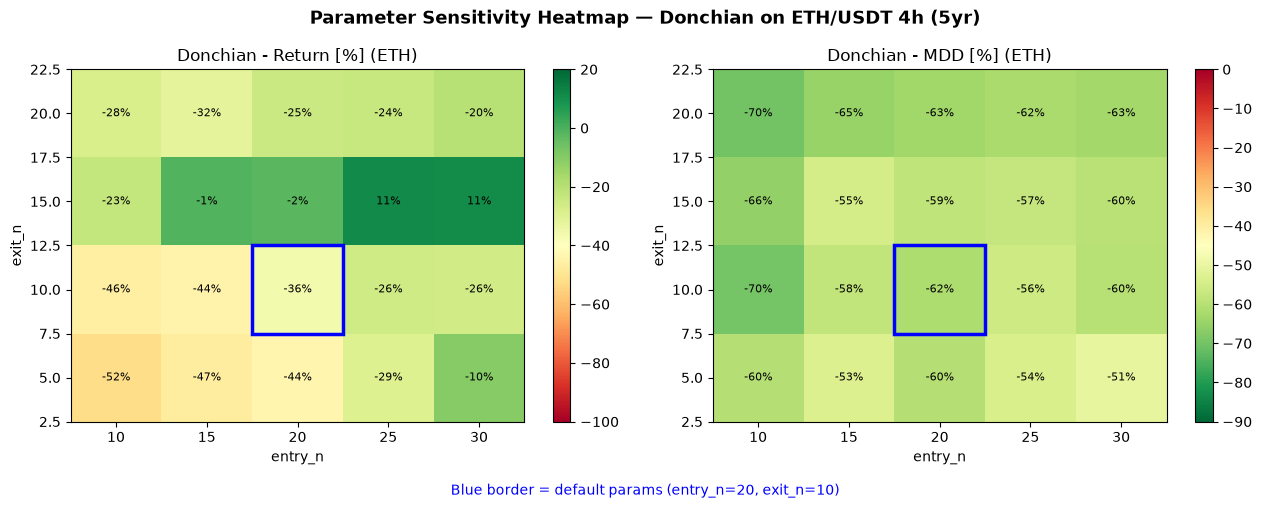

,조합수,수익>0 비율,B&H낙폭방어 비율,기본 20/10 Return,기본 20/10 MDD
0,20,10%,100%,-36.0%,-61.6%


In [5]:
# 축2 히트맵 시각화 (Return + MDD, BTC 노트북과 동일 방식, 기본값 20/10 칸 강조)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Parameter Sensitivity Heatmap — Donchian on ETH/USDT 4h (5yr)", fontsize=13, fontweight="bold")

DEFAULT = (20, 10)  # entry_n, exit_n

# Return heatmap
ret_pivot = don_sweep.pivot(index="exit_n", columns="entry_n", values="Return [%]")
ax = axes[0]
im = ax.pcolormesh(ret_pivot.columns, ret_pivot.index,
                   ret_pivot.values, cmap="RdYlGn", vmin=-100, vmax=20)
for en in ret_pivot.index:
    for ex in ret_pivot.columns:
        val = ret_pivot.loc[en, ex]
        if not np.isnan(val):
            ax.text(ex, en, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")
ax.set_xlabel("entry_n")
ax.set_ylabel("exit_n")
ax.set_title("Donchian - Return [%] (ETH)")
plt.colorbar(im, ax=ax)
ax.add_patch(mpatches.Rectangle(
    (DEFAULT[0] - 2.5, DEFAULT[1] - 2.5), 5, 5,
    linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
))

# MDD heatmap
mdd_pivot = don_sweep.pivot(index="exit_n", columns="entry_n", values="Max. Drawdown [%]")
ax = axes[1]
im2 = ax.pcolormesh(mdd_pivot.columns, mdd_pivot.index,
                    mdd_pivot.values, cmap="RdYlGn_r", vmin=-90, vmax=0)
for en in mdd_pivot.index:
    for ex in mdd_pivot.columns:
        val = mdd_pivot.loc[en, ex]
        if not np.isnan(val):
            ax.text(ex, en, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")
ax.set_xlabel("entry_n")
ax.set_ylabel("exit_n")
ax.set_title("Donchian - MDD [%] (ETH)")
plt.colorbar(im2, ax=ax)
ax.add_patch(mpatches.Rectangle(
    (DEFAULT[0] - 2.5, DEFAULT[1] - 2.5), 5, 5,
    linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
))

fig.text(0.5, 0.01, "Blue border = default params (entry_n=20, exit_n=10)", ha="center", fontsize=10, color="blue")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

# 요약 표
summary = pd.DataFrame([{
    "조합수":        len(don_sweep),
    "수익>0 비율":   f"{pos_rate:.0f}%",
    "B&H낙폭방어 비율": f"{def_rate:.0f}%",
    "기본 20/10 Return": f"{d_base['Return [%]']:+.1f}%",
    "기본 20/10 MDD":    f"{d_base['Max. Drawdown [%]']:+.1f}%",
}])
display(summary)

In [6]:
# 축3 워크포워드 k=5
wf = walk_forward(df, DonchianBreakout, k=5, entry_n=20, exit_n=10)

rows = []
for _, row in wf.iterrows():
    seg = df.loc[row["start"]:row["end"]]
    bh  = buy_hold(seg)
    defend = row["Max. Drawdown [%]"] > bh["Max. Drawdown [%]"]
    rows.append({
        "구간":       f"seg{int(row['segment'])}",
        "기간":       f"{row['start'].date()}~{row['end'].date()}",
        "봉수":       len(seg),
        "전략 수익%": round(row["Return [%]"], 1),
        "전략 MDD%":  round(row["Max. Drawdown [%]"], 1),
        "Sharpe":    round(row["Sharpe Ratio"], 2),
        "거래수":     int(row["# Trades"]),
        "B&H 수익%": round(bh["Return [%]"], 1),
        "B&H MDD%":  round(bh["Max. Drawdown [%]"], 1),
        "낙폭방어":  "✓" if defend else "✗",
    })

wf_tbl = pd.DataFrame(rows).set_index("구간")
print("=== 축3 워크포워드 (k=5): Donchian (entry_n=20, exit_n=10) on ETH/USDT 4h ===")
display(wf_tbl)

defend_cnt = sum(1 for r in rows if r["낙폭방어"] == "✓")
pos_cnt    = sum(1 for r in rows if r["전략 수익%"] > 0)
print(f"\n수익>0: {pos_cnt}/5구간 | 낙폭방어: {defend_cnt}/5구간")
print(f"→ 축3 기준 통과 (≥3구간 방어): {'✅' if defend_cnt >= 3 else '❌'} {defend_cnt}/5")

=== 축3 워크포워드 (k=5): Donchian (entry_n=20, exit_n=10) on ETH/USDT 4h ===


,기간,봉수,전략 수익%,전략 MDD%,Sharpe,거래수,B&H 수익%,B&H MDD%,낙폭방어
구간,,,,,,,,,
seg0,2021-06-29~2022-06-29,2189,-31.8,-50.4,-1.1,36,-47.4,-81.1,✓
seg1,2022-06-29~2023-06-29,2190,-7.3,-39.7,-0.2,36,62.6,-46.2,✓
seg2,2023-06-29~2024-06-28,2190,20.9,-27.9,0.5,28,87.3,-29.4,✓
seg3,2024-06-28~2025-06-28,2190,-24.6,-45.9,-0.8,35,-29.5,-65.1,✓
seg4,2025-06-28~2026-06-28,2190,13.1,-36.5,0.3,29,-35.2,-68.0,✓



수익>0: 2/5구간 | 낙폭방어: 5/5구간
→ 축3 기준 통과 (≥3구간 방어): ✅ 5/5


---
## 판정

> `docs/design/phase-3b-eth.md` 결과 섹션 인용.

### Sanity 체크 — FULL 구간 숫자

| 항목 | 값 |
|---|---|
| Donchian (entry_n=20, exit_n=10) 수익% | **-36.0%** |
| Donchian MDD% | **-61.6%** |
| ETH B&H MDD% | **-81.1%** |

---

### ✅ Donchian(4h) — ETH out-of-asset 통과

**3축 모두 통과 → 낙폭방어 엣지가 BTC→ETH로 재현됐다.**

- **축1 OOS**: OOS 구간에서 MDD 방어 재현 (+24.3%p, -43.7% vs -68.0%)  
- **축2 파라미터 민감도**: 20조합 전부 B&H보다 MDD 얕음 (방어 100%)  
- **축3 워크포워드**: 5/5 구간 전부 B&H 대비 낙폭 방어 (수익>0은 2/5)

이는 이 엣지가 **BTC 전용 우연이 아니라 크립토 추세추종의 구조적 성질**일 가능성을 높인다.  
→ **Donchian(4h)은 "낙폭 방어 도구"로서 Phase 4 페이퍼 후보 확정 (BTC+ETH 2자산 근거).**

---

### ⚠️ 단: "수익기는 아님" 동일

ETH는 이 기간 약세 자산 — 절대수익은 거의 음수였다.  
하는 일은 일관되게 **"낙폭 막기"**. BTC·ETH 어디서도 B&H 총수익을 이기지 못한다.

---

### 정직한 한계

1. **ETH도 크립토 베타** — BTC와 높은 상관관계(ρ~0.8). 진정한 독립 검증은 아니다.  
   "크립토 추세추종 일반화"는 가능하나 "자산 간 독립 검증"으로 보기는 어렵다.
2. **ETH 약세장 편향** — 이 5년 구간에서 ETH가 하락했기 때문에 낙폭방어가 잘 보이는 구간이다.  
   강세장에서 같은 엣지가 보일지는 별도 검증이 필요하다.
3. **단일 역사 경로** — 두 자산 모두 한 가지 시나리오만 봤다. 통계적 보장이 아님.

---

### 다음 단계

Phase 4: **BTC+ETH 2자산 Donchian 페이퍼 트레이딩** (테스트넷 또는 소액 실험)